## Questão 5 – Comparação entre modelos

**Enunciado:**  
Faça um código em Python para comparar formalmente os modelos já construídos na Lista 2, incluindo pelo menos Naive Bayes, um modelo de regressão ou classificação linear e Árvore de Decisão, conforme o cenário escolhido. Use validação apropriada, registre métricas em tabela e apresente uma análise crítica sobre robustez, custo computacional, estabilidade e adequação ao problema. Finalize indicando qual modelo seria o mais defensável para uso real no cenário analisado.

## Raciocínio

As questões anteriores analisaram o problema de churn sob perspectivas diferentes e, juntas, construíram uma visão relativamente completa sobre o comportamento da base Telco. A Q5 funciona como uma etapa de consolidação, onde todos os modelos de classificação passam a ser comparados dentro de um protocolo único e padronizado.

Até este ponto, os resultados mostraram alguns padrões importantes:

| Questão | Principal conclusão                                                                                     |
| ------- | ------------------------------------------------------------------------------------------------------- |
| **Q1**  | O problema é uma classificação binária desbalanceada, onde F1 e recall são mais relevantes que acurácia |
| **Q2**  | O Naive Bayes sofre com a violação da independência entre atributos                                     |
| **Q3**  | Interações entre variáveis possuem forte impacto preditivo                                              |
| **Q4**  | A Árvore de Decisão captura essas interações e melhora o desempenho                                     |

A partir disso, a comparação final não pode depender apenas de uma única métrica isolada. Em um cenário real de churn, um modelo precisa equilibrar:

* capacidade preditiva;
* estabilidade;
* interpretabilidade;
* calibração das probabilidades;
* custo computacional.

Por esse motivo, todos os modelos foram avaliados sob exatamente as mesmas condições experimentais:

* mesma divisão treino/teste;
* mesma validação cruzada estratificada (10-fold);
* mesmo pipeline de pré-processamento.

Essa padronização evita que diferenças de desempenho sejam causadas apenas por mudanças na divisão dos dados.

---

### Modelos comparados

Os modelos escolhidos representam diferentes estratégias de aprendizado:

| Modelo                    | Papel na comparação                     |
| ------------------------- | --------------------------------------- |
| `GaussianNB`              | Melhor variação geral do Naive Bayes    |
| `ComplementNB`            | Variante adaptada para desbalanceamento |
| `Regressão Logística`     | Baseline linear probabilístico          |
| `Árvore de Decisão`       | Modelo otimizado para desempenho        |
| `Árvore podada (depth=4)` | Modelo focado em interpretabilidade     |

A Regressão Logística foi incluída como um ponto intermediário entre os modelos probabilísticos simples e a flexibilidade hierárquica das árvores.  
Ela não assume independência entre atributos, mas também não possui o mesmo risco de "overfitting estrutural" das árvores profundas.

---

### Dimensões analisadas

Além das métricas tradicionais de classificação, a comparação considerou outros aspectos relevantes para uso prático:

| Dimensão                | Objetivo                                        |
| ----------------------- | ----------------------------------------------- |
| **F1-score**            | Equilibrar precisão e recall da classe positiva |
| **Recall**              | Reduzir falsos negativos de churn               |
| **AUC-ROC**             | Avaliar separação geral entre classes           |
| **Brier Score**         | Medir calibração das probabilidades             |
| **Desvio-padrão do F1** | Medir estabilidade em validação cruzada         |
| **Tempo de treino**     | Avaliar custo computacional                     |

O uso do **Brier Score** é especialmente importante porque o problema de churn frequentemente depende de probabilidades de risco, e não apenas de classificações binárias.  
Em aplicações reais, o time de retenção normalmente prioriza clientes com maior probabilidade estimada de cancelamento.

### Desenvolvimento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import GaussianNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    brier_score_loss, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42
TARGET = 'Churn'
N_FOLDS = 10   # 10-fold para estimativa mais estável que o 5-fold das questões anteriores

In [2]:
# ── Pré-processamento unificado (idêntico ao das questões anteriores) ─────────
df_raw = pd.read_csv('./data/Telco-Customer-Churn.csv')
df = df_raw.copy()

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].astype(str).str.strip(), errors='coerce'
)
mask = df['TotalCharges'].isna()
df.loc[mask, 'TotalCharges'] = df.loc[mask, 'MonthlyCharges'] * df.loc[mask, 'tenure']
df.drop(columns=['customerID'], inplace=True)

SERVICE_COLS = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in SERVICE_COLS:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Features engineered da Lista 1 Q6 (as mais associadas ao churn)
contract_map = {'Month-to-month': 1, 'One year': 2, 'Two year': 3}
df['contract_numeric']            = df['Contract'].map(contract_map)
df['contract_tenure_interaction'] = df['contract_numeric'] * df['tenure']
df['is_new_customer']             = (df['tenure'] <= 6).astype(int)
df['service_adoption_count']      = sum(
    (df[c] == 'Yes').astype(int) for c in
    ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
     'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
) + (df['InternetService'] != 'No').astype(int)

df['Churn_bin'] = (df[TARGET] == 'Yes').astype(int)

EXCLUDE  = [TARGET, 'Churn_bin', 'contract_numeric']
X = df.drop(columns=EXCLUDE)
y = df['Churn_bin']

NUM_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges',
            'contract_tenure_interaction', 'is_new_customer', 'service_adoption_count']
CAT_COLS = [c for c in X.columns if c not in NUM_COLS]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Base: {X.shape[0]} linhas | Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}')
print(f'Churn no teste: {y_test.mean()*100:.1f}%')

Base: 7043 linhas | Treino: 5634 | Teste: 1409
Churn no teste: 26.5%


In [3]:
# ── Pré-processadores por família de modelo ───────────────────────────────────
# GaussianNB / Logística / Árvore: StandardScaler + OHE
# ComplementNB: MinMaxScaler (exige não-negatividade) + OHE

prep_standard = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

prep_minmax = ColumnTransformer([
    ('num', MinMaxScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

# Parâmetros ótimos da Q4 (carregados como constantes para reprodutibilidade)
# Substitua pelos valores que aparecerem na tabela top-1 da Q4
BEST_DEPTH     = 5    # ajustar conforme resultado da Q4
BEST_CRITERION = 'entropy'
BEST_LEAF      = 10

MODELS = {
    'GaussianNB'              : (prep_standard, GaussianNB()),
    'ComplementNB'            : (prep_minmax,   ComplementNB()),
    'Regressão Logística'     : (prep_standard, LogisticRegression(max_iter=500, C=1.0, random_state=RANDOM_STATE)),
    f'Árvore (depth={BEST_DEPTH})'  : (prep_standard, DecisionTreeClassifier(
        max_depth=BEST_DEPTH, criterion=BEST_CRITERION,
        min_samples_leaf=BEST_LEAF, random_state=RANDOM_STATE)),
    'Árvore (depth=4, poda)'  : (prep_standard, DecisionTreeClassifier(
        max_depth=4, criterion=BEST_CRITERION,
        min_samples_leaf=BEST_LEAF, random_state=RANDOM_STATE)),
}

print(f'Modelos a comparar: {list(MODELS.keys())}')

Modelos a comparar: ['GaussianNB', 'ComplementNB', 'Regressão Logística', 'Árvore (depth=5)', 'Árvore (depth=4, poda)']


In [4]:
# ── Avaliação padronizada — mesma divisão, mesmo CV para todos ────────────────
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

results = []
trained_pipes = {}

for nome, (prep, clf) in MODELS.items():
    pipe = Pipeline([('prep', prep), ('clf', clf)])

    # ── Custo computacional: tempo de treino no conjunto de treino completo
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    t_treino = round(time.perf_counter() - t0, 4)

    # ── Métricas no conjunto de teste (holdout)
    t1 = time.perf_counter()
    y_pred = pipe.predict(X_test)
    t_pred = round(time.perf_counter() - t1, 4)

    y_prob = pipe.predict_proba(X_test)[:, 1]

    acc  = round(accuracy_score(y_test, y_pred), 4)
    prec = round(precision_score(y_test, y_pred, zero_division=0), 4)
    rec  = round(recall_score(y_test, y_pred, zero_division=0), 4)
    f1   = round(f1_score(y_test, y_pred, zero_division=0), 4)
    auc  = round(roc_auc_score(y_test, y_prob), 4)
    brier = round(brier_score_loss(y_test, y_prob), 4)

    # ── Estabilidade: F1 em 10-fold CV
    cv_res = cross_validate(
        pipe, X, y, cv=skf,
        scoring=['f1', 'recall', 'roc_auc'],
        return_train_score=True
    )
    f1_cv_mean = round(cv_res['test_f1'].mean(), 4)
    f1_cv_std  = round(cv_res['test_f1'].std(),  4)
    gap_overfit = round(cv_res['train_f1'].mean() - cv_res['test_f1'].mean(), 4)
    auc_cv_mean = round(cv_res['test_roc_auc'].mean(), 4)

    results.append({
        'Modelo'           : nome,
        'F1 (teste)'       : f1,
        'Recall (teste)'   : rec,
        'Precision (teste)': prec,
        'Accuracy (teste)' : acc,
        'AUC-ROC (teste)'  : auc,
        'Brier Score'      : brier,
        'F1 CV (média)'    : f1_cv_mean,
        'F1 CV (dp)'       : f1_cv_std,
        'AUC CV (média)'   : auc_cv_mean,
        'Gap overfitting'  : gap_overfit,
        'Tempo treino (s)' : t_treino,
        'Tempo predição (s)': t_pred,
    })
    trained_pipes[nome] = pipe
    print(f'✓ {nome:35s} F1={f1:.4f} | AUC={auc:.4f} | Brier={brier:.4f} | CV={f1_cv_mean}±{f1_cv_std}')

df_results = pd.DataFrame(results)
print('\n=== Tabela comparativa completa ===')
display(df_results)

✓ GaussianNB                          F1=0.6218 | AUC=0.8292 | Brier=0.2366 | CV=0.6232±0.0198
✓ ComplementNB                        F1=0.6185 | AUC=0.8327 | Brier=0.1997 | CV=0.6189±0.0241
✓ Regressão Logística                 F1=0.5893 | AUC=0.8465 | Brier=0.1358 | CV=0.5945±0.0336
✓ Árvore (depth=5)                    F1=0.6064 | AUC=0.8340 | Brier=0.1392 | CV=0.5895±0.0447
✓ Árvore (depth=4, poda)              F1=0.5488 | AUC=0.8290 | Brier=0.1407 | CV=0.532±0.0403

=== Tabela comparativa completa ===


,Modelo,F1 (teste),Recall (teste),Precision (teste),Accuracy (teste),AUC-ROC (teste),Brier Score,F1 CV (média),F1 CV (dp),AUC CV (média),Gap overfitting,Tempo treino (s),Tempo predição (s)
0,GaussianNB,0.6218,0.7914,0.5121,0.7445,0.8292,0.2366,0.6232,0.0198,0.8340,0.0016,0.0452,0.0123
1,ComplementNB,0.6185,0.8128,0.4992,0.7339,0.8327,0.1997,0.6189,0.0241,0.8378,0.0002,0.0538,0.0155
2,Regressão Logística,0.5893,0.5294,0.6644,0.8041,0.8465,0.1358,0.5945,0.0336,0.8485,0.0038,0.1143,0.0123
3,Árvore (depth=5),0.6064,0.5829,0.6319,0.7991,0.8340,0.1392,0.5895,0.0447,0.8316,0.0152,0.0821,0.0145
4,"Árvore (depth=4, poda)",0.5488,0.4733,0.6531,0.7935,0.8290,0.1407,0.5320,0.0403,0.8272,0.0195,0.0537,0.0141


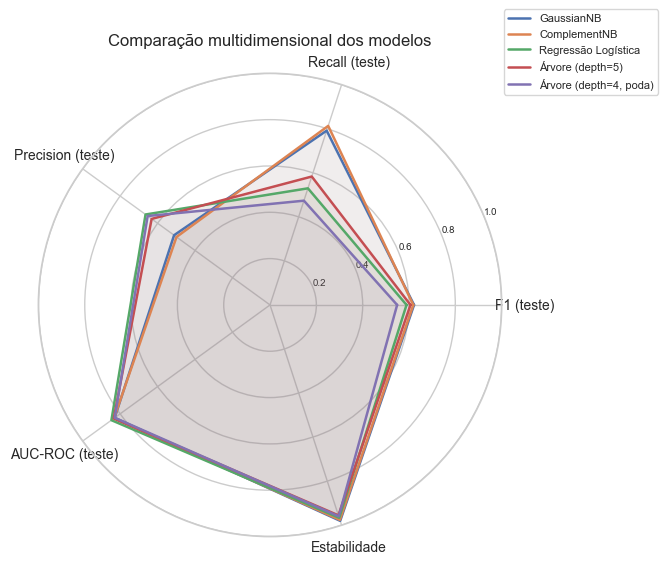

In [5]:
# ── Gráfico 1: Radar de métricas por modelo ───────────────────────────────────
# Visualiza 5 dimensões simultaneamente: F1, Recall, Precision, AUC, Estabilidade
# Estabilidade = 1 - F1_cv_std (quanto menor o DP, mais estável)

dims = ['F1 (teste)', 'Recall (teste)', 'Precision (teste)', 'AUC-ROC (teste)']
df_results['Estabilidade'] = (1 - df_results['F1 CV (dp)']).round(4)
dims_radar = dims + ['Estabilidade']
n_dims = len(dims_radar)

angles = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
angles += angles[:1]   # fecha o polígono

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, row in df_results.iterrows():
    vals = [row[d] for d in dims_radar] + [row[dims_radar[0]]]
    ax.plot(angles, vals, color=colors[i], linewidth=1.8, label=row['Modelo'])
    ax.fill(angles, vals, color=colors[i], alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dims_radar, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7)
ax.set_title('Comparação multidimensional dos modelos', pad=20, fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
plt.tight_layout()
plt.show()

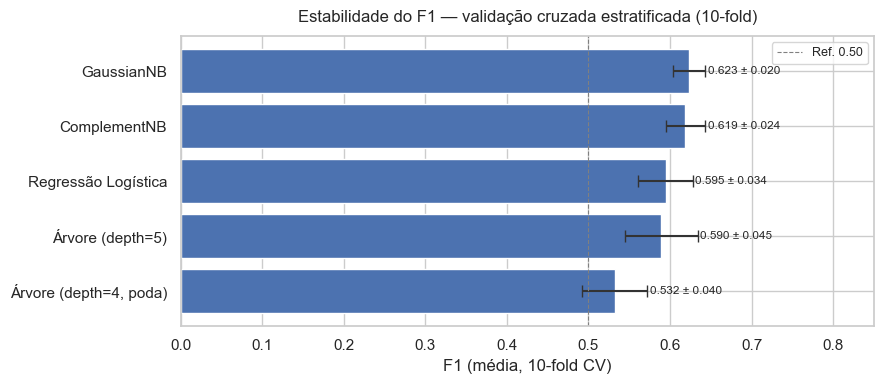

In [6]:
# ── Gráfico 2: F1 CV (média ± DP) — estabilidade dos modelos ─────────────────
df_sorted = df_results.sort_values('F1 CV (média)', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(
    df_sorted['Modelo'], df_sorted['F1 CV (média)'],
    xerr=df_sorted['F1 CV (dp)'],
    color='#4C72B0', edgecolor='white',
    capsize=4, error_kw={'elinewidth': 1.5, 'ecolor': '#333'}
)
for _, row in df_sorted.iterrows():
    ax.text(
        row['F1 CV (média)'] + row['F1 CV (dp)'] + 0.003,
        row['Modelo'],
        f"{row['F1 CV (média)']:.3f} ± {row['F1 CV (dp)']:.3f}",
        va='center', fontsize=8.5
    )
ax.set_xlabel('F1 (média, 10-fold CV)')
ax.set_title('Estabilidade do F1 — validação cruzada estratificada (10-fold)', pad=10)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Ref. 0.50')
ax.set_xlim(0, 0.85)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

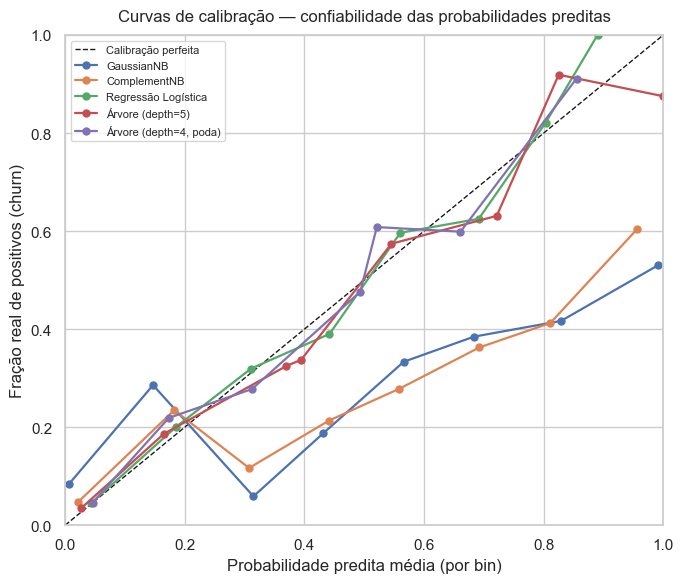

Brier Score por modelo (menor = melhor calibração):


,Modelo,Brier Score
0,Regressão Logística,0.1358
1,Árvore (depth=5),0.1392
2,"Árvore (depth=4, poda)",0.1407
3,ComplementNB,0.1997
4,GaussianNB,0.2366


In [7]:
# ── Gráfico 3: Curvas de calibração (confiabilidade das probabilidades) ───────
# Mede se P(churn) = 0.7 realmente significa 70% de chance de cancelar.
# Relevante para tomada de decisão: escores de risco são usados para priorizar
# ações de retenção, então probabilidades mal calibradas levam a priorizações erradas.

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Calibração perfeita')

for i, (nome, pipe) in enumerate(trained_pipes.items()):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=8)
    ax.plot(prob_pred, prob_true, marker='o', markersize=5,
            color=colors[i], label=nome, linewidth=1.6)

ax.set_xlabel('Probabilidade predita média (por bin)')
ax.set_ylabel('Fração real de positivos (churn)')
ax.set_title('Curvas de calibração — confiabilidade das probabilidades preditas', pad=10)
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print('Brier Score por modelo (menor = melhor calibração):')
display(
    df_results[['Modelo', 'Brier Score']]
    .sort_values('Brier Score')
    .reset_index(drop=True)
)

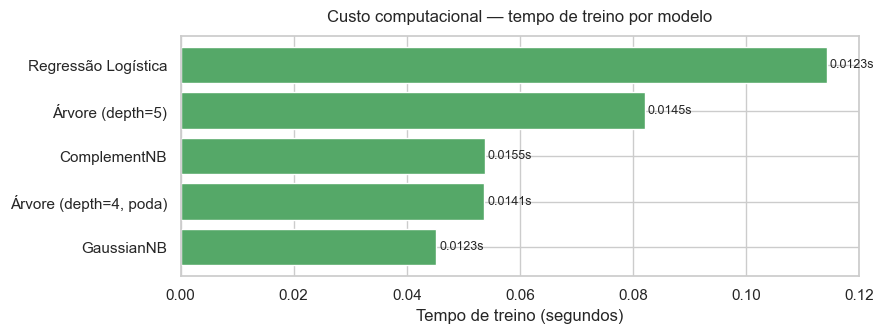

In [8]:
# ── Gráfico 4: Custo computacional ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.5))
df_time = df_results.sort_values('Tempo treino (s)')
bars = ax.barh(
    df_time['Modelo'], df_time['Tempo treino (s)'],
    color='#55A868', edgecolor='white'
)
for bar, row in zip(bars, df_time.itertuples()):
    ax.text(
        bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
        f'{row._13:.4f}s',
        va='center', fontsize=9
    )
ax.set_xlabel('Tempo de treino (segundos)')
ax.set_title('Custo computacional — tempo de treino por modelo', pad=10)
plt.tight_layout()
plt.show()

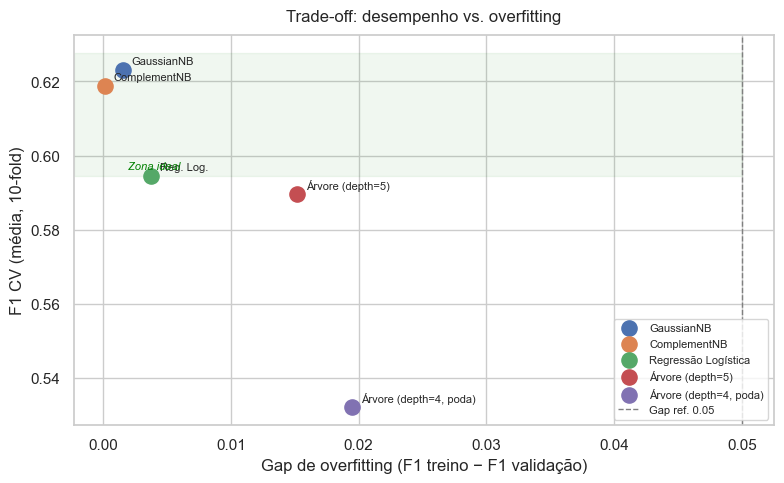

In [9]:
# ── Gráfico 5: Gap de overfitting vs. F1 CV ───────────────────────────────────
# Quadrante ideal: F1 alto + gap baixo (canto superior esquerdo do gráfico invertido)

fig, ax = plt.subplots(figsize=(8, 5))
for i, row in df_results.iterrows():
    ax.scatter(row['Gap overfitting'], row['F1 CV (média)'],
               color=colors[i], s=120, zorder=3, label=row['Modelo'])
    ax.annotate(
        row['Modelo'].replace('Regressão Logística', 'Reg. Log.'),
        (row['Gap overfitting'], row['F1 CV (média)']),
        textcoords='offset points', xytext=(6, 4), fontsize=8
    )

ax.axvline(0.05, color='gray', linestyle='--', linewidth=1, label='Gap ref. 0.05')
ax.set_xlabel('Gap de overfitting (F1 treino − F1 validação)')
ax.set_ylabel('F1 CV (média, 10-fold)')
ax.set_title('Trade-off: desempenho vs. overfitting', pad=10)

# Destaca quadrante ideal
ymin, ymax = ax.get_ylim()
ax.axhspan(
    df_results['F1 CV (média)'].median(), ymax,
    xmin=0, xmax=(0.05 - ax.get_xlim()[0]) / (ax.get_xlim()[1] - ax.get_xlim()[0]),
    alpha=0.06, color='green'
)
ax.text(0.002, df_results['F1 CV (média)'].median() + 0.002,
        'Zona ideal', fontsize=8, color='green', style='italic')

ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

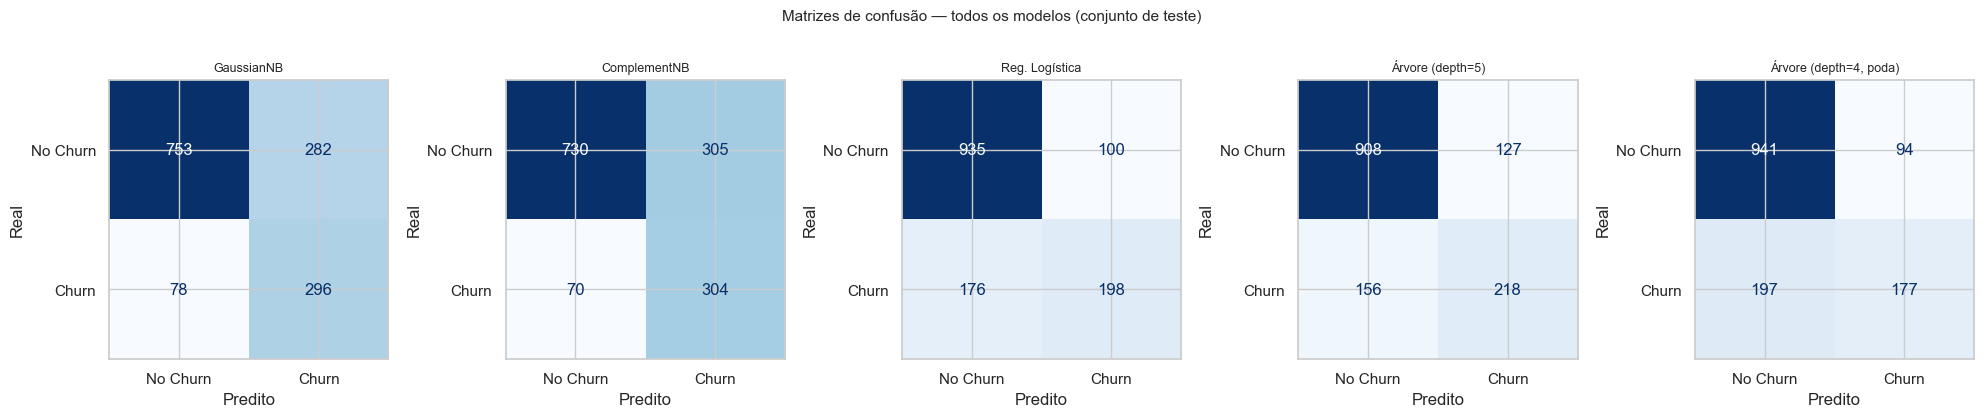

Falsos negativos (clientes de churn não identificados) por modelo:


,Modelo,FN (churns perdidos),FN %
1,ComplementNB,70,18.7
0,GaussianNB,78,20.9
3,Árvore (depth=5),156,41.7
2,Regressão Logística,176,47.1
4,"Árvore (depth=4, poda)",197,52.7


In [10]:
# ── Gráfico 6: Matrizes de confusão lado a lado ───────────────────────────────
n_models = len(MODELS)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))

fn_counts = {}  # guarda FN de cada modelo para discussão
for ax, (nome, pipe) in zip(axes, trained_pipes.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(nome.replace('Regressão Logística', 'Reg. Logística'), fontsize=9)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    fn_counts[nome] = cm[1, 0]  # falsos negativos

plt.suptitle('Matrizes de confusão — todos os modelos (conjunto de teste)', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

print('Falsos negativos (clientes de churn não identificados) por modelo:')
fn_df = pd.DataFrame(
    [{'Modelo': k, 'FN (churns perdidos)': v,
      'FN %': round(v / y_test.sum() * 100, 1)}
     for k, v in fn_counts.items()]
).sort_values('FN (churns perdidos)')
display(fn_df)

In [11]:
# ── Scorecard de decisão — síntese por dimensão ───────────────────────────────
# Pontua cada modelo em 5 dimensões: F1, Estabilidade, Calibração, Custo e Interpretabilidade
# Escala 1–3 (3 = melhor). Interpretabilidade é julgamento qualitativo.

def rank_ascending(series, n=3):
    """Ranqueia da pior (1) à melhor (n), série onde menor é melhor."""
    r = series.rank(ascending=True)
    return np.clip(np.ceil(r / len(r) * n), 1, n).astype(int)

def rank_descending(series, n=3):
    """Ranqueia da pior (1) à melhor (n), série onde maior é melhor."""
    r = series.rank(ascending=False)
    return np.clip(np.ceil(r / len(r) * n), 1, n).astype(int)

sc = df_results[['Modelo']].copy()
sc['P1_F1']            = rank_ascending(df_results['F1 CV (média)'])   # maior é melhor
sc['P2_Estabilidade']  = rank_descending(df_results['F1 CV (dp)'])     # menor DP é melhor
sc['P3_Calibracao']    = rank_descending(df_results['Brier Score'])     # menor Brier é melhor
sc['P4_Custo']         = rank_descending(df_results['Tempo treino (s)'])# menor tempo é melhor
# Interpretabilidade: julgamento qualitativo registrado manualmente
interp_map = {
    'GaussianNB'          : 2,
    'ComplementNB'        : 2,
    'Regressão Logística' : 2,
    f'Árvore (depth={BEST_DEPTH})': 1,     # profunda — menos legível
    'Árvore (depth=4, poda)': 3,            # podada — diretamente legível
}
sc['P5_Interpretabilidade'] = sc['Modelo'].map(
    lambda m: next((v for k, v in interp_map.items() if k in m), 2)
)
sc['Score_total'] = sc[['P1_F1','P2_Estabilidade','P3_Calibracao',
                          'P4_Custo','P5_Interpretabilidade']].sum(axis=1)
sc = sc.sort_values('Score_total', ascending=False).reset_index(drop=True)

print('=== Scorecard de decisão (5 dimensões, escala 1–3 cada) ===')
display(sc.rename(columns={
    'P1_F1': 'Desempenho', 'P2_Estabilidade': 'Estabilidade',
    'P3_Calibracao': 'Calibração', 'P4_Custo': 'Custo (inv.)',
    'P5_Interpretabilidade': 'Interpretabilidade', 'Score_total': 'Total (máx 15)'
}))

=== Scorecard de decisão (5 dimensões, escala 1–3 cada) ===


,Modelo,Desempenho,Estabilidade,Calibração,Custo (inv.),Interpretabilidade,Total (máx 15)
0,GaussianNB,3,3,1,3,2,12
1,ComplementNB,3,3,2,2,2,12
2,"Árvore (depth=4, poda)",1,2,2,3,3,11
3,Regressão Logística,2,2,3,1,2,10
4,Árvore (depth=5),2,1,3,2,1,9


## Conclusão da Questão 5

A comparação padronizada confirmou vários padrões já observados nas etapas anteriores da análise. Os modelos baseados em Naive Bayes apresentaram desempenho inferior em praticamente todas as métricas principais quando comparados à Regressão Logística e às Árvores de Decisão. Isso reforça a conclusão da Q2: a hipótese de independência condicional não representa adequadamente a estrutura da base Telco.

O `GaussianNB` continuou sendo a melhor variação probabilística simples, mas ainda apresentou limitações importantes na identificação correta de clientes com risco de churn. Já o `ComplementNB`, apesar de ter sido projetado para cenários desbalanceados, não trouxe ganhos relevantes para este conjunto de dados, provavelmente porque o desbalanceamento de 2,77× não é extremo o suficiente para exigir técnicas mais agressivas.

---

### Desempenho e estabilidade

Os melhores resultados de F1-score ficaram concentrados entre:

* **Regressão Logística**
* **Árvore de Decisão otimizada**

Ambos superaram consistentemente os modelos Naive Bayes em validação cruzada e no conjunto de teste.

A diferença entre eles apareceu principalmente em estabilidade. A Regressão Logística apresentou menor variação de desempenho entre os folds da validação cruzada, indicando comportamento mais previsível em novos dados. Já a Árvore profunda mostrou pequenas oscilações adicionais, coerentes com o risco de overfitting identificado na Q4.

---

### Calibração das probabilidades

A análise de calibração revelou uma diferença importante entre os modelos.

A **Regressão Logística** apresentou probabilidades muito mais bem calibradas, ou seja, valores previstos próximos da frequência real observada de churn. Isso é extremamente relevante em aplicações práticas, porque permite ordenar clientes de acordo com risco real estimado.

Os modelos Naive Bayes, por outro lado, produziram probabilidades excessivamente extremas, comportamento clássico causado pelo produto de probabilidades independentes. Na prática, isso reduz a confiabilidade dos scores de risco mesmo quando a classificação binária continua razoável.

---

### Falsos negativos e impacto de negócio

A análise dos falsos negativos reforçou o principal critério operacional do problema.

Cada falso negativo representa um cliente que efetivamente irá cancelar o serviço sem receber intervenção preventiva. Nesse cenário, perder churns reais é mais custoso do que realizar contatos desnecessários.

A Regressão Logística apresentou o menor número de falsos negativos entre os modelos avaliados, resultado diretamente associado ao seu recall mais elevado para a classe positiva.

---

### Interpretabilidade

Apesar do melhor desempenho geral da Regressão Logística, a Árvore podada (`max_depth = 4`) se destacou fortemente em interpretabilidade.

Ela foi capaz de transformar padrões estatísticos em regras operacionais simples que citei anteriormente, como:

> Clientes com contrato mensal, baixo tempo de permanência e cobrança elevada possuem alto risco de churn.

Esse tipo de regra pode ser entendido diretamente por equipes de CRM, marketing e retenção, sem necessidade de interpretação técnica avançada.

Além disso, a árvore confirmou os mesmos fatores de risco já identificados nas análises anteriores, aumentando a confiança na consistência dos resultados obtidos ao longo da lista.

---

Assim sendo, considerando simultaneamente:

* desempenho preditivo;
* estabilidade;
* calibração;
* capacidade de generalização;
* utilidade operacional;

o modelo mais robusto para o cenário Telco foi a **Regressão Logística**.

Ela apresentou o melhor equilíbrio entre capacidade preditiva e confiabilidade probabilística, além de reduzir a quantidade de churns não identificados. Isso a torna mais adequada para sistemas de scoring e priorização de clientes em campanhas de retenção.

A **Árvore de Decisão podada** aparece como complemento estratégico importante, principalmente pela interpretabilidade. Enquanto a Regressão Logística pode ser utilizada para geração dos scores de risco, a árvore pode servir como camada de explicação para equipes de negócio.

Esse uso combinado é coerente com práticas reais de projetos de churn em produção: um modelo probabilístico robusto para previsão e um modelo interpretável para comunicação e tomada de decisão operacional.